In [2]:
import pandas as pd

# 1. Load the raw datasets
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

# 2. Data Cleaning: Replace missing values (NaN) with standard 'None' strings
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('None')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('None')
deliveries['fielder'] = deliveries['fielder'].fillna('None')

# 3. Date Formatting: Standardize date format to YYYY-MM-DD
matches['date'] = pd.to_datetime(matches['date'])

# 4. Export: Save the cleaned datasets as new files
deliveries.to_csv('cleaned_deliveries.csv', index=False)
matches.to_csv('cleaned_matches.csv', index=False)

print("[SUCCESS] Step 1 Complete: Datasets cleaned and exported successfully.")


[SUCCESS] Step 1 Complete: Datasets cleaned and exported successfully.


In [3]:
import sqlite3

# 1. Establish an in-memory SQL connection
conn = sqlite3.connect(':memory:')

# 2. Write DataFrames into the local SQL database as structured tables
deliveries.to_sql('deliveries', conn, index=False, if_exists='replace')
matches.to_sql('matches', conn, index=False, if_exists='replace')

# 3. SQL Query: Extract top 10 death overs specialists (Overs 16-20)
query = """
SELECT 
    bowler,
    COUNT(*) AS total_balls_bowled,
    SUM(total_runs) AS total_runs_conceded,
    ROUND((SUM(total_runs) * 1.0 / COUNT(*)) * 6.0, 2) AS death_economy_rate,
    COUNT(CASE WHEN player_dismissed != 'None' AND dismissal_kind != 'run out' THEN 1 END) AS total_wickets
FROM deliveries
WHERE over >= 16
GROUP BY bowler
HAVING COUNT(*) >= 120
ORDER BY death_economy_rate ASC, total_wickets DESC
LIMIT 10;
"""

# 4. Execute query and store results in a new DataFrame
death_bowlers_metrics = pd.read_sql_query(query, conn)

print("--- SQL Execution Successful: Death Overs Performance Metrics ---")
print(death_bowlers_metrics)

--- SQL Execution Successful: Death Overs Performance Metrics ---
              bowler  total_balls_bowled  total_runs_conceded  \
0          SP Narine                 664                  790   
1       DE Bollinger                 242                  297   
2         SL Malinga                1050                 1300   
3           A Kumble                 174                  217   
4           MA Starc                 210                  265   
5  Mustafizur Rahman                 168                  212   
6           R Ashwin                 379                  479   
7           DW Steyn                 624                  806   
8      Harmeet Singh                 135                  178   
9           M Kartik                 155                  207   

   death_economy_rate  total_wickets  
0                7.14             52  
1                7.36             23  
2                7.43             96  
3                7.48             17  
4                7.57  

In [4]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Generating Death Overs Performance Metrics Chart ---


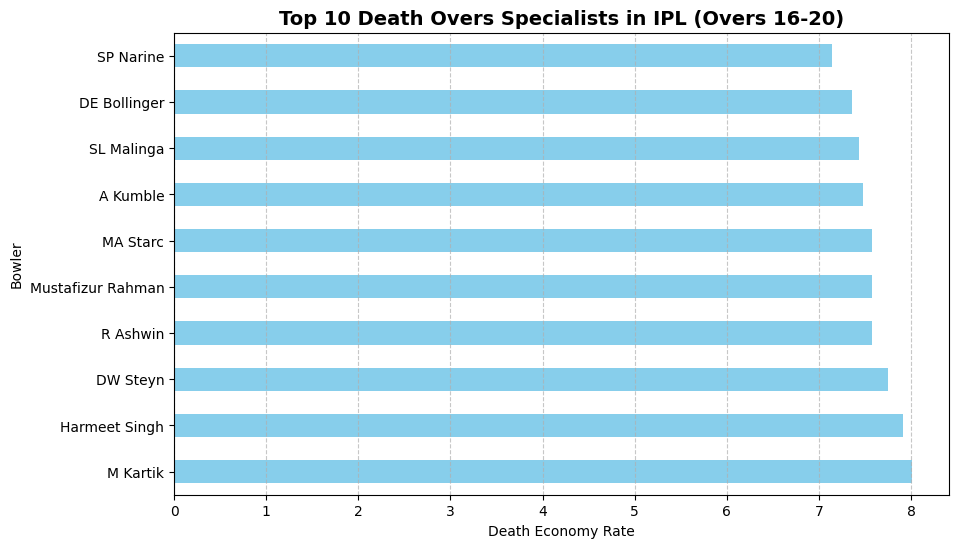

In [5]:
# No extra library needed, pure pandas visualization
print("--- Generating Death Overs Performance Metrics Chart ---")

# Using pandas inbuilt plot function to create a horizontal bar chart
ax = death_bowlers_metrics.plot(
    x='bowler', 
    y='death_economy_rate', 
    kind='barh', 
    figsize=(10, 6), 
    color='skyblue', 
    legend=False
)

# Invert y-axis to show the best bowler on top
ax.invert_yaxis()

# Add labels
ax.set_title('Top 10 Death Overs Specialists in IPL (Overs 16-20)', fontsize=14, fontweight='bold')
ax.set_xlabel('Death Economy Rate')
ax.set_ylabel('Bowler')

ax.grid(axis='x', linestyle='--', alpha=0.7)

--- Generating Professional Sorted Chart ---


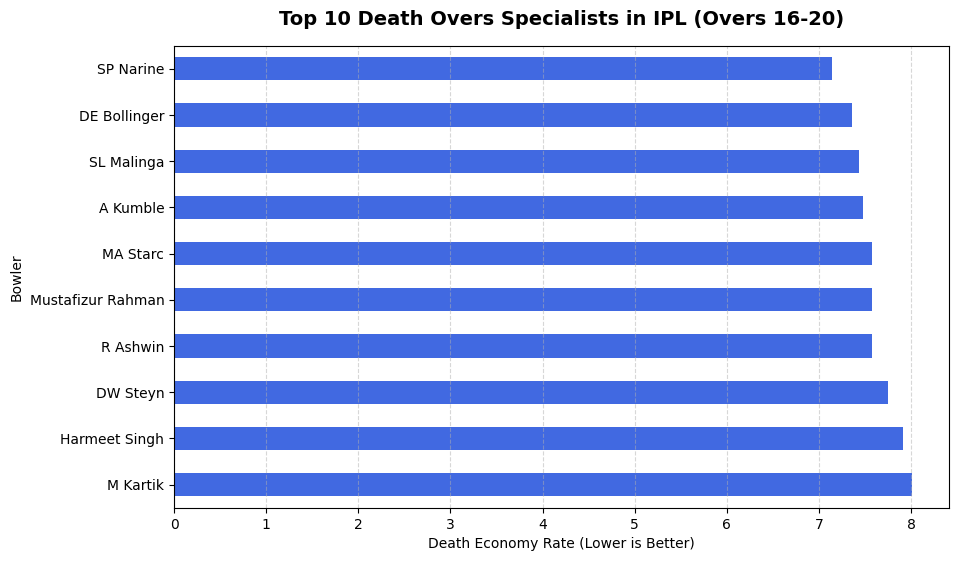

In [6]:
# Sorted chart for recruiters
print("--- Generating Professional Sorted Chart ---")
sorted_metrics = death_bowlers_metrics.sort_values(by='death_economy_rate', ascending=True)

ax = sorted_metrics.plot(
    x='bowler', 
    y='death_economy_rate', 
    kind='barh', 
    figsize=(10, 6), 
    color='royalblue', 
    legend=False
)
ax.invert_yaxis()  # Best economy rate at the top
ax.set_title('Top 10 Death Overs Specialists in IPL (Overs 16-20)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Death Economy Rate (Lower is Better)')
ax.set_ylabel('Bowler')
ax.grid(axis='x', linestyle='--', alpha=0.5)

--- Calculating Advanced Death Overs Metrics (Overs 16-20) ---


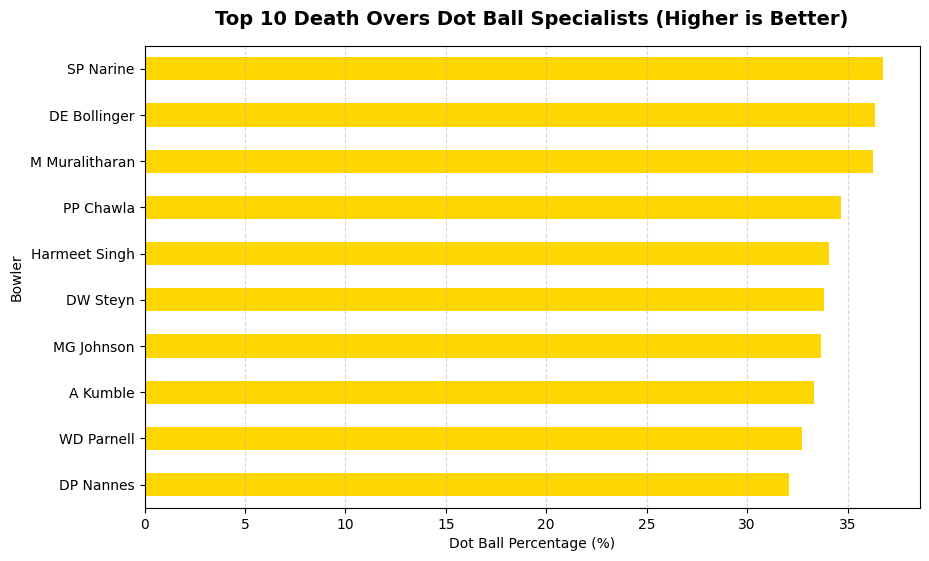

In [7]:
# Step 4: Advanced Boundary & Dot Ball Analytics
print("--- Calculating Advanced Death Overs Metrics (Overs 16-20) ---")

advanced_query = """
SELECT 
    bowler,
    COUNT(ball) AS total_balls,
    SUM(CASE WHEN total_runs = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(ball) AS dot_ball_percentage,
    SUM(CASE WHEN batsman_runs IN (4, 6) THEN 1 ELSE 0 END) * 100.0 / COUNT(ball) AS boundary_percentage
FROM deliveries
WHERE over >= 16
GROUP BY bowler
HAVING total_balls >= 120
ORDER BY dot_ball_percentage DESC
LIMIT 10;
"""

# Fetch advanced metrics from our in-memory SQL database
advanced_metrics = pd.read_sql_query(advanced_query, conn)

# Plotting the Dot Ball Specialist Bowlers
ax2 = advanced_metrics.plot(
    x='bowler', 
    y='dot_ball_percentage', 
    kind='barh', 
    figsize=(10, 6), 
    color='gold', 
    legend=False
)
ax2.invert_yaxis()
ax2.set_title('Top 10 Death Overs Dot Ball Specialists (Higher is Better)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Dot Ball Percentage (%)')
ax2.set_ylabel('Bowler')
ax2.grid(axis='x', linestyle='--', alpha=0.5)